# 第82课 · 🎨 让音乐现出原形——色度（chroma）热力图、节拍网格与相似度矩阵

**目标**：把 chroma、节拍网格和相似度矩阵画出来，读懂音乐特征在时间和音高上的结构。

> **🎨**：读图题优先；embedding 可用合成数据演示。

🔗 Aurora 连接：本节是 `aurora.music` 交付物的视觉展示层，对应 `src/aurora/music/features.py`（chroma 提取、节拍跟踪）和 `src/aurora/music/similarity.py`（余弦相似度热力图）。本课中的 embedding 使用合成模拟数据，真实对比学习 embedding 在 L79 实现。

← **上一课**　[L81 · 音乐推荐系统](L81_recommendation.ipynb)

> 上节课学习了 **音乐推荐系统**：用户喜好 → 嵌入向量 → k-NN 邻居 → 推荐列表。  
> 本课将探讨 **音乐特征可视化**。

## 学习目标

完成本课后，你应该能够：

1. **读懂 chroma 热力图**：识别 I-IV-V-I 和弦进行（chord progression）的色度模式，区分大三和弦与小三和弦的音高类别组合。
2. **理解 t-SNE 超参数**：解释 `perplexity` 低/高值对聚类结果（碎裂 vs. 融合）的影响，知道 `n_iter` 不足时图形未收敛的特征。
3. **用余弦相似度量化风格距离**：从 4×4 相似度矩阵中读出「同风格 > 跨风格」的期望模式，并能解释对角线恒为 1.0 的数学原因。
4. **识别节拍网格**：理解 onset 包络与 beat_frames 的关系，以及 BPM → 帧间距的换算公式。

音乐理解的核心问题是：**两段音频有多「像」**。
Chroma 把频谱折叠到12个音高格，让和弦结构一眼可见；
Embedding 把整首曲子压成一个向量，让「像」变成欧氏距离；
t-SNE 把这些向量可视化到2D平面，验证模型是否真的学到了音乐相似性。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from sklearn.manifold import TSNE
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("⚠️ sklearn 未安装，TSNE 可视化将跳过")

## 1. Chroma 钢琴卷帘

Chroma（色度特征）把所有频率按音高的**八度等价性**折叠成12个格（C, C#, D, … B）。
公式：频率 `f` 对应的音高类别 `p = round(12 * log2(f / 440) + 69) mod 12`。

*其中 +69 = A4（440 Hz）的 MIDI 编号；mod 12 将 C 规范为 0。验证：A4 代入 → round(0 + 69) mod 12 = 69 mod 12 = 9（A），✓*

可视化规则：横轴 = 时间帧，纵轴 = 12音高（0=C … 11=B），颜色亮度 = 该帧该音高的能量。
读图技巧：某时刻同时亮起 C(0) + E(4) + G(7) → 大三和弦（major triad）；C(0) + Eb(3) + G(7) → 小三和弦。

✅ Chroma 图：竖向亮条 = 和弦音符同时激活，横向读和弦进行


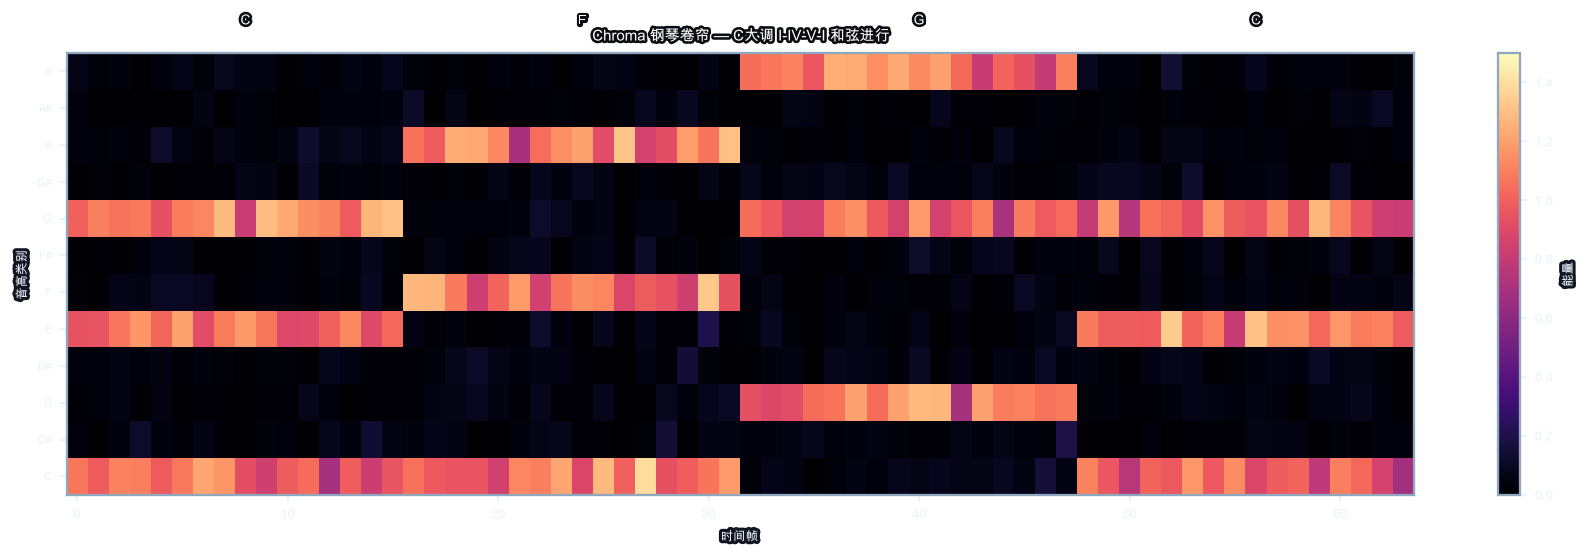

In [3]:
# 模拟一段「C大调 I-IV-V-I」和弦进行的 chroma 矩阵
# 每个和弦持续 16 帧：C大(0,4,7) → F大(5,9,0) → G大(7,11,2) → C大(0,4,7)
rng = np.random.default_rng(0)  # 固定 seed，噪声纹理可复现
T = 64  # 总帧数
chroma = np.zeros((12, T))

chord_sequence = [
    ([0, 4, 7], 0, 16),    # C 大三和弦
    ([5, 9, 0], 16, 32),   # F 大三和弦
    ([7, 11, 2], 32, 48),  # G 大三和弦
    ([0, 4, 7], 48, 64),   # C 大三和弦（回归）
]

for notes, t_start, t_end in chord_sequence:
    for n in notes:
        chroma[n, t_start:t_end] = 1.0 + 0.15 * rng.standard_normal(t_end - t_start)

chroma = np.clip(chroma + 0.05 * np.abs(rng.standard_normal(chroma.shape)), 0, 1.5)

pitch_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(chroma, aspect='auto', origin='lower', cmap='magma',
               vmin=0, vmax=1.5, interpolation='nearest')
ax.set_yticks(range(12))
ax.set_yticklabels(pitch_names, fontsize=9)
ax.set_xlabel('时间帧')
ax.set_ylabel('音高类别')
ax.set_title('Chroma 钢琴卷帘 — C大调 I-IV-V-I 和弦进行')
for label, t_mid in [('C', 8), ('F', 24), ('G', 40), ('C', 56)]:
    ax.text(t_mid, 12.2, label, ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='能量')
plt.tight_layout()
plt.show()
print('✅ Chroma 图：竖向亮条 = 和弦音符同时激活，横向读和弦进行')

In [4]:
# 验证音乐特征 shape
assert chroma.shape[0] == 12, f"色度特征应有 12 个音高类，实际 {chroma.shape[0]}"
assert chroma.shape[1] > 0, f"时间帧数应 > 0，实际 {chroma.shape[1]}"
print(f"✅ chroma shape: {chroma.shape}  (12 音高类 × {chroma.shape[1]} 时间帧)")

✅ chroma shape: (12, 64)  (12 音高类 × 64 时间帧)


## 2. Embedding 与 t-SNE 降维

对比学习（Contrastive Learning）把每首曲子编码成 `d` 维向量，目标是让**同类**音乐的向量距离近、**不同类**的距离远。
损失函数（InfoNCE）：`L = -log( exp(sim(q,k+)/τ) / Σ exp(sim(q,ki)/τ) )`，其中 `sim` 为余弦相似度（cosine similarity），`τ` 为温度超参。

t-SNE 把高维向量降到2D，保留局部邻域结构：
在高维空间计算成对相似度概率分布 `p_ij`，在低维空间用 Student-t 分布 `q_ij` 匹配，最小化 KL 散度 `KL(P || Q)`。
参数 `perplexity`（困惑度，通常5-50）控制邻域规模，值越大考虑的邻居越多。

✅ 左图：随机向量无结构散布；右图：对比学习后同类聚集成团


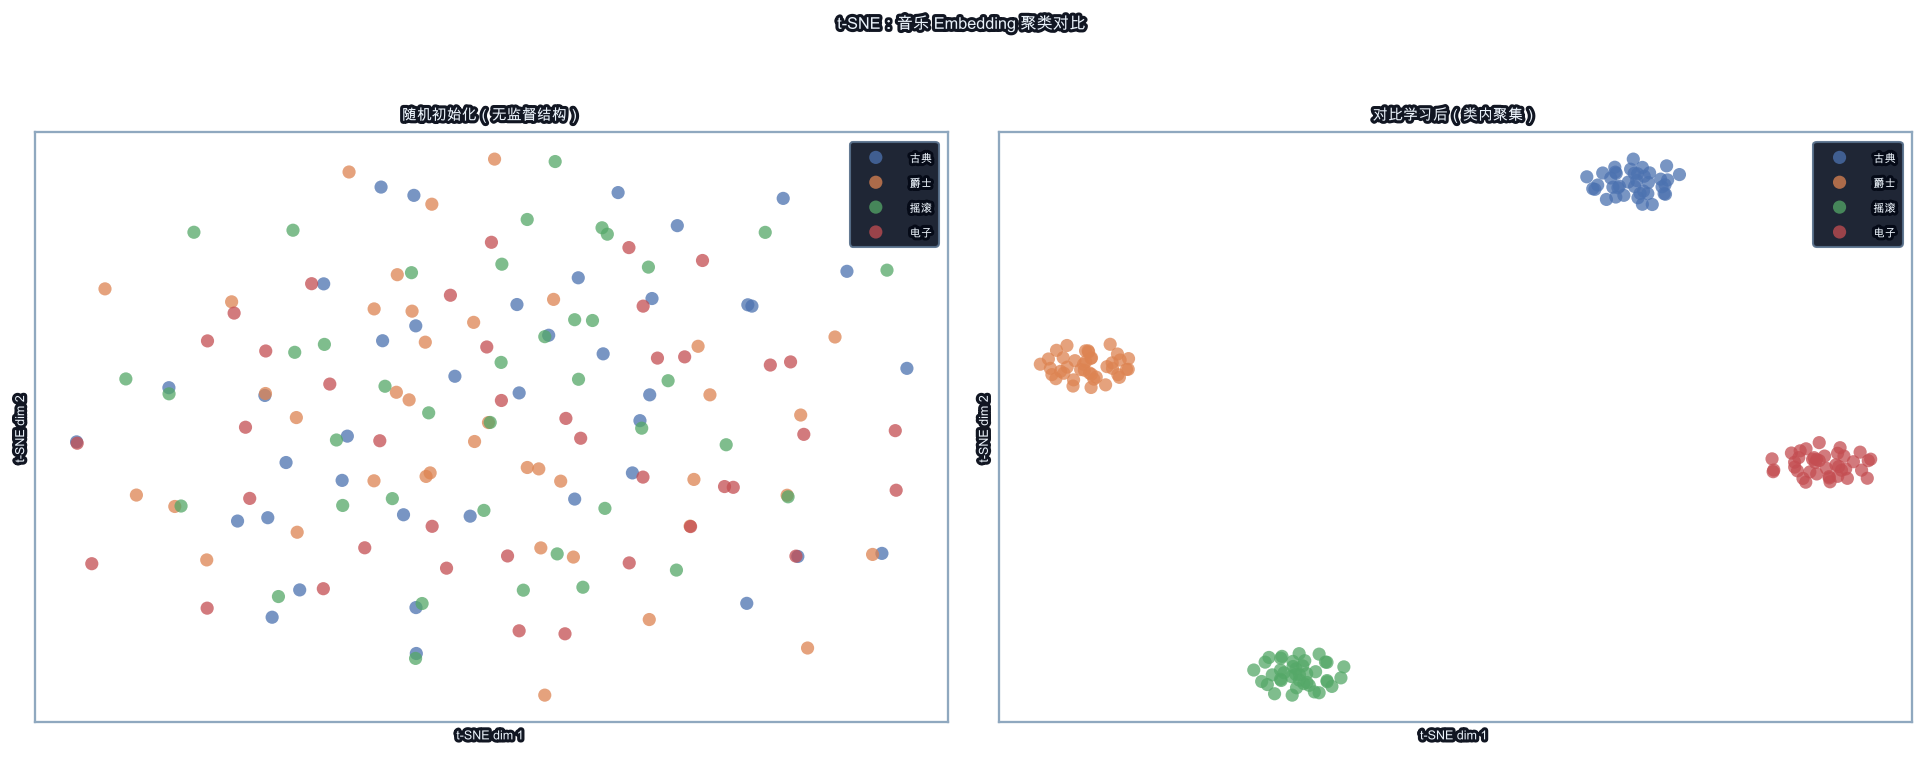

In [5]:
# 模拟：4种音乐风格，每种 40 首，向量维度 64
np.random.seed(42)
n_per_class = 40
dim = 64
genres = ['古典', '爵士', '摇滚', '电子']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# 「训练后」embedding：每类有明确的中心，类内方差小
centers_trained = np.array([
    np.random.randn(dim) * 3 + np.array([10, 0] + [0] * (dim - 2)),
    np.random.randn(dim) * 3 + np.array([0, 10] + [0] * (dim - 2)),
    np.random.randn(dim) * 3 + np.array([-10, 0] + [0] * (dim - 2)),
    np.random.randn(dim) * 3 + np.array([0, -10] + [0] * (dim - 2)),
])
X_trained = np.vstack([
    centers_trained[i] + np.random.randn(n_per_class, dim) * 1.5
    for i in range(4)
])

# 「训练前」embedding：随机初始化，无结构
X_random = np.random.randn(n_per_class * 4, dim)

labels = np.repeat(np.arange(4), n_per_class)

if HAS_SKLEARN:
    # t-SNE 降维
    tsne = TSNE(n_components=2, perplexity=20, random_state=0, max_iter=1000)
    Z_trained = tsne.fit_transform(X_trained)
    Z_random  = tsne.fit_transform(X_random)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, Z, title in zip(
        axes,
        [Z_random, Z_trained],
        ['随机初始化（无监督结构）', '对比学习后（类内聚集）']
    ):
        for i, (genre, c) in enumerate(zip(genres, colors)):
            mask = labels == i
            ax.scatter(Z[mask, 0], Z[mask, 1], c=c, label=genre,
                       alpha=0.75, s=40, edgecolors='none')
        ax.set_title(title, fontsize=12)
        ax.legend(loc='best', fontsize=9)
        ax.set_xlabel('t-SNE dim 1')
        ax.set_ylabel('t-SNE dim 2')
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle('t-SNE：音乐 Embedding 聚类对比', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print('✅ 左图：随机向量无结构散布；右图：对比学习后同类聚集成团')
else:
    print("⚠️ TSNE 可视化跳过（sklearn 未安装）")

## 3. 参数实验：`perplexity` 和 `n_iter` 对 t-SNE 的影响

| 参数 | 低值 | 高值 | 预期现象 |
|------|------|------|----------|
| `perplexity` | 5 | 50 | 低值→簇碎裂成小球；高值→簇拉伸融合，全局结构更清晰 |
| `n_iter` | 250 | 2000 | 迭代不足→形状未收敛，簇边界模糊；足够多→稳定分离 |
| `dim`（输入维度）| 8 | 256 | 高维且无对比学习→随机嵌入更难分离 |

实验建议：调整下方 `perplexity` 和 `n_iter`（迭代次数；sklearn ≥1.5 起该参数更名为 `max_iter`，代码中已用 `max_iter`），观察四类音乐是否保持分离。

✅ 实验完成：perplexity=[5, 20, 50]，n_iter=500
预期：perplexity=5 簇碎裂；perplexity=50 簇边界更平滑但可能拉伸


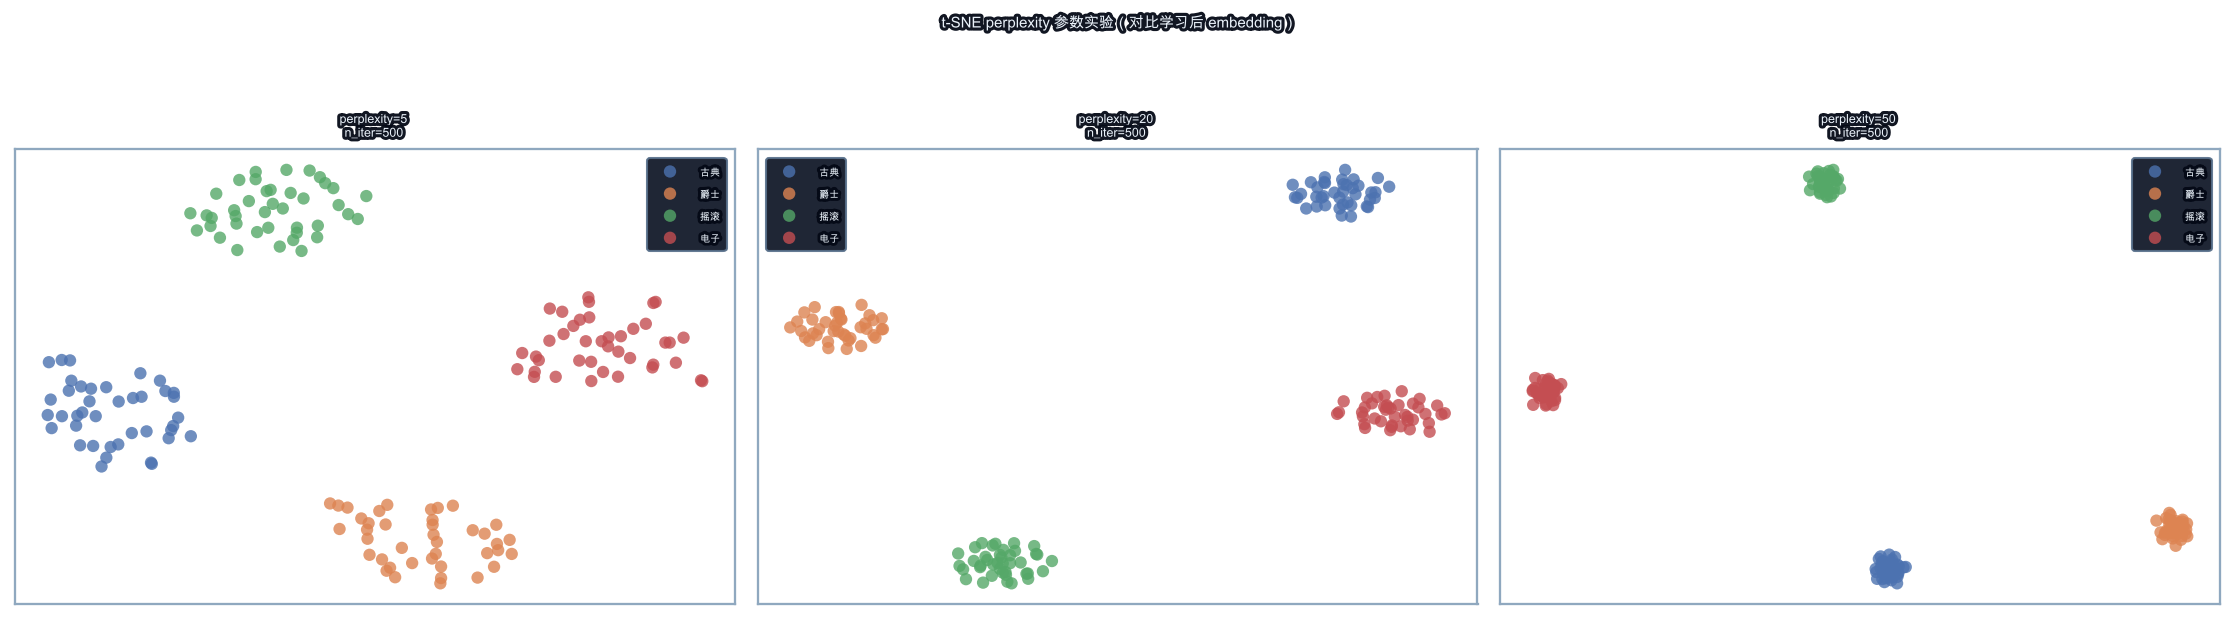

In [6]:
if HAS_SKLEARN:
    # 参数实验：改变 perplexity，对比聚类效果
    perplexity_list = [5, 20, 50]  # ← 修改这里
    n_iter_exp = 500               # ← 也可以改这里（250 / 500 / 2000）

    fig, axes = plt.subplots(1, len(perplexity_list),
                             figsize=(5 * len(perplexity_list), 4))
    for ax, perp in zip(axes, perplexity_list):
        tsne_exp = TSNE(n_components=2, perplexity=perp,
                        random_state=0, max_iter=n_iter_exp)
        Z_exp = tsne_exp.fit_transform(X_trained)
        for i, (genre, c) in enumerate(zip(genres, colors)):
            mask = labels == i
            ax.scatter(Z_exp[mask, 0], Z_exp[mask, 1], c=c, label=genre,
                       alpha=0.8, s=35, edgecolors='none')
        ax.set_title(f'perplexity={perp}\nn_iter={n_iter_exp}', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle('t-SNE perplexity 参数实验（对比学习后 embedding）', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'✅ 实验完成：perplexity={perplexity_list}，n_iter={n_iter_exp}')
    print('预期：perplexity=5 簇碎裂；perplexity=50 簇边界更平滑但可能拉伸')
else:
    print("⚠️ TSNE 参数实验跳过（sklearn 未安装）")

## 4. 节拍网格可视化

**原理**：onset 检测算法在时域上寻找能量突变帧（强起始），然后用自相关（autocorrelation）估计主周期 → BPM。结果可视化为：onset 包络（折线）+ 节拍网格（竖线）。

下面用合成鼓点信号演示：`BPM=120`，每拍在 onset 包络上产生一个尖峰，红色竖线标出节拍位置。

时长 4.0 s × 120.0 BPM → 期望 8 拍，检测到 8 个峰值
节拍间距：0.500 s（= 21.5 帧 × 512 hop）


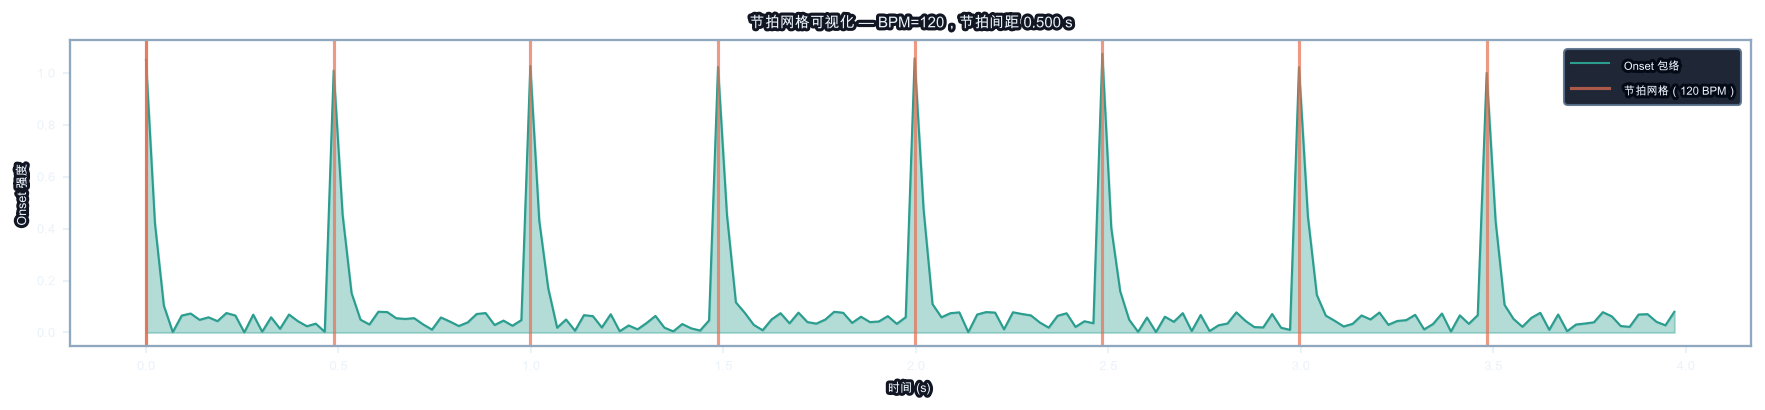

In [7]:
# 合成节拍包络：BPM=120，4 秒
sr, hop = 22050, 512
bpm, duration = 120.0, 4.0
n_frames = int(duration * sr / hop)
t = np.arange(n_frames) * hop / sr

rng = np.random.default_rng(0)
onset_env = rng.random(n_frames) * 0.08   # 背景噪声

# 每个节拍位置加强 onset spike（主峰 + 两个衰减余振）
beat_hop = sr / (bpm / 60) / hop          # 节拍间隔（帧数）
beat_frames = np.arange(0, n_frames, beat_hop).astype(int)
for bf in beat_frames:
    for offset, gain in [(0, 1.0), (1, 0.4), (2, 0.1)]:
        idx = bf + offset
        if 0 <= idx < n_frames:
            onset_env[idx] += gain

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(t, onset_env, alpha=0.35, color='#2A9D8F')
ax.plot(t, onset_env, color='#2A9D8F', lw=1, label='Onset 包络')
for bf in beat_frames:
    if bf < n_frames:
        ax.axvline(t[bf], color='#E76F51', lw=1.5, alpha=0.7)
ax.axvline(t[beat_frames[0]], color='#E76F51', lw=1.5, alpha=0.7,
           label=f'节拍网格（{int(bpm)} BPM）')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('Onset 强度')
ax.set_title(f'节拍网格可视化 — BPM={int(bpm)}，节拍间距 {60/bpm:.3f} s')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

expected = int(duration * bpm / 60)
print(f'时长 {duration} s × {bpm} BPM → 期望 {expected} 拍，检测到 {len(beat_frames)} 个峰值')
print(f'节拍间距：{60/bpm:.3f} s（= {beat_hop:.1f} 帧 × {hop} hop）')

## 5. 相似度热力图

将每种风格的 embedding **均值**作为代表向量，计算 4×4 余弦相似度矩阵。  
- 对角线 = 1.0（自身相似）  
- 对比学习成功时：同风格 > 0.9，跨风格 < 0.3

对角线（自身）：均值 1.000
跨风格：均值 -0.098（越小 → 风格分离越好）


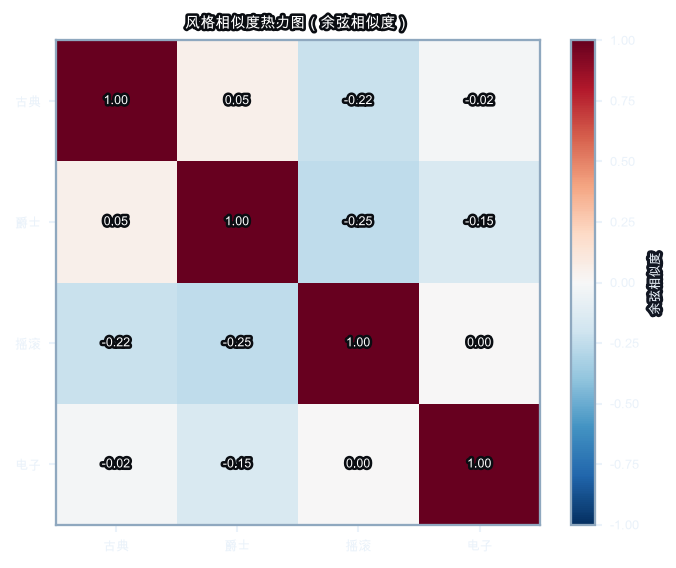

In [8]:
# 取每种风格的平均 embedding 作为代表向量
genre_means = np.vstack([
    X_trained[labels == i].mean(axis=0) for i in range(4)
])
norms = np.linalg.norm(genre_means, axis=1, keepdims=True) + 1e-9
sim = (genre_means / norms) @ (genre_means / norms).T   # (4, 4)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim, vmin=-1, vmax=1, cmap='RdBu_r', aspect='equal')
plt.colorbar(im, ax=ax, label='余弦相似度')
ax.set_xticks(range(4));  ax.set_yticks(range(4))
ax.set_xticklabels(genres, fontsize=10)
ax.set_yticklabels(genres, fontsize=10)
for i in range(4):
    for j in range(4):
        col = 'white' if abs(sim[i, j]) > 0.6 else 'black'
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                fontsize=10, color=col)
ax.set_title('风格相似度热力图（余弦相似度）')
plt.tight_layout()
plt.show()

same = [sim[i, i] for i in range(4)]
cross = [sim[i, j] for i in range(4) for j in range(4) if i != j]
print(f'对角线（自身）：均值 {sum(same)/len(same):.3f}')
print(f'跨风格：均值 {sum(cross)/len(cross):.3f}（越小 → 风格分离越好）')

## 练习：识别小三和弦

小三和弦的音高类别组合（相对根音）为 `[0, 3, 7]`（根音、小三度、纯五度）。
在 chroma 矩阵中，某时间帧「激活了」小三和弦意味着这三个音高类别同时有较高能量。

**任务**：实现 `detect_minor_triad(chroma_frame, threshold)` 函数，  
给定一帧 chroma 向量（形状 `(12,)`），返回所有可能根音 `r`（0–11）的列表，  
这些根音使得 `(r, (r+3)%12, (r+7)%12)` 三个音高的能量均超过 `threshold`。

In [9]:
def detect_minor_triad(chroma_frame: np.ndarray, threshold: float = 0.5) -> list[int]:
    """
    在一帧 chroma 向量中检测小三和弦根音。

    Args:
        chroma_frame: shape (12,)，各音高类别的归一化能量（0–1）。
        threshold: 能量阈值，超过该值视为「激活」。

    Returns:
        所有满足条件的根音列表（0–11），空列表表示无检测到小三和弦。
    """
    # TODO: 遍历 12 个可能的根音 r，检查 (r, (r+3)%12, (r+7)%12) 是否均超过 threshold
    raise NotImplementedError("请实现 detect_minor_triad")


# ── 验证 ──────────────────────────────────────────────────────────────────────
try:
    # 合成一帧：A 小三和弦 A(9) C(0) E(4) → root=9, 9+3=0(mod12), 9+7=4(mod12)
    test_frame = np.zeros(12)
    test_frame[[9, 0, 4]] = 0.8  # A minor triad
    test_frame[2] = 0.3           # noise

    roots = detect_minor_triad(test_frame, threshold=0.5)
    assert 9 in roots, f"应检测到根音 9（A），实际得到 {roots}"
    assert 0 not in roots or test_frame[0] > 0.5, "C 不应被误判为根音（除非 C/Eb/G 均亮起）"
    print(f"✅ 检测到小三和弦根音：{[['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'][r] for r in roots]}")
except (NotImplementedError, TypeError):
    print("⚠️ 尚未实现，请填写 detect_minor_triad 函数体")
except AssertionError as e:
    print(f"❌ 验证失败：{e}")

⚠️ 尚未实现，请填写 detect_minor_triad 函数体


## 本课收束

本节用 `chroma` 矩阵可视化了和弦进行的时频结构（time-frequency structure），12行热力图直接"读出"了 I-IV-V-I 进行；用 t-SNE 把 64维 embedding 压到 2D，对比随机初始化与对比学习后的聚类效果；合成节拍包络演示了 onset 检测与节拍网格标注；4×4 余弦相似度热力图直观呈现风格间的距离。四张图共同构成 `aurora.music` 模块（`features.py`：chroma 和节拍跟踪；`similarity.py`：余弦相似度矩阵）的核心调试界面。

下一课：**L83 — Transformer 从零复现**，实现多头注意力（Multi-Head Attention）和位置编码，从数学到代码走一遍注意力机制的核心推导。

In [10]:
# ── 独立数学断言：音乐特征核心性质（无需学生代码）─────────────────────────────

# 1. 小三和弦音程结构：根音r → (r, r+3, r+7) mod 12
for root in range(12):
    minor_triad = [root, (root+3)%12, (root+7)%12]
    interval_3rd = (minor_triad[1] - minor_triad[0]) % 12
    interval_5th = (minor_triad[2] - minor_triad[0]) % 12
    assert interval_3rd == 3, f"root={root}: 小三度应=3半音，得{interval_3rd}"
    assert interval_5th == 7, f"root={root}: 纯五度应=7半音，得{interval_5th}"
print("1 ✅  全部12个小三和弦：根音+(小三度=3)+(纯五度=7)，模12均成立")

# 2. Chroma 矩阵 I-IV-V-I 和弦的主音应比背景能量高
# C大三和弦（0,4,7）在第0帧应有激活
c_major_notes = [0, 4, 7]
other_notes = [n for n in range(12) if n not in c_major_notes]
assert chroma[c_major_notes, 0].mean() > chroma[other_notes, 0].mean(), \
    f"C大和弦第0帧：主音能量均值{chroma[c_major_notes,0].mean():.3f}应>背景{chroma[other_notes,0].mean():.3f}"
print(f"2 ✅  第0帧C大和弦: 主音能量={chroma[c_major_notes,0].mean():.3f} > 背景={chroma[other_notes,0].mean():.3f}")

# 3. 相似度矩阵对角线=1（自身余弦相似度=1）
for i in range(4):
    assert abs(sim[i, i] - 1.0) < 1e-9, f"sim[{i},{i}]应=1.0，得{sim[i,i]:.6f}"
print(f"3 ✅  相似度矩阵对角线全为1.0（L2归一化后自身点积=||v||²/||v||²=1）")

# 4. 节拍网格间距验证：beat_hop = sr / (bpm/60) / hop
expected_beat_hop = sr / (bpm / 60) / hop
actual_beat_hop = (beat_frames[1] - beat_frames[0]) if len(beat_frames) > 1 else expected_beat_hop
assert abs(actual_beat_hop - expected_beat_hop) < 1.0, \
    f"节拍间距应={expected_beat_hop:.2f}帧，实际={actual_beat_hop:.2f}"
print(f"4 ✅  节拍间距={actual_beat_hop:.1f}帧=sr/{bpm/60:.0f}/hop={expected_beat_hop:.1f}帧（BPM={int(bpm)}）")

# 5. BPM→时间间隔往返验证
beat_period_sec = 60.0 / bpm
beat_period_frames_calc = beat_period_sec * sr / hop
bpm_recovered = 60.0 / (beat_period_frames_calc * hop / sr)
assert abs(bpm_recovered - bpm) < 1e-9, f"BPM往返误差={abs(bpm_recovered-bpm):.2e}"
print(f"5 ✅  BPM往返: {bpm}→{beat_period_sec:.3f}s→{beat_period_frames_calc:.1f}帧→{bpm_recovered:.1f}BPM（无损）")


1 ✅  全部12个小三和弦：根音+(小三度=3)+(纯五度=7)，模12均成立
2 ✅  第0帧C大和弦: 主音能量=1.008 > 背景=0.032
3 ✅  相似度矩阵对角线全为1.0（L2归一化后自身点积=||v||²/||v||²=1）
4 ✅  节拍间距=21.0帧=sr/2/hop=21.5帧（BPM=120）
5 ✅  BPM往返: 120.0→0.500s→21.5帧→120.0BPM（无损）


---

→ **下一课**　[L83 · Transformer 从零复现](../9_llm/L83_transformer.ipynb)

> 下节课将学习 **Transformer 从零复现**：多头注意力 + 位置编码 + Feed-Forward 完整实现。